# HDB Resale Price — Time-Series Forecast

A step-by-step walkthrough that builds a monthly resale-price forecast and benchmarks **eight** approaches on the same hold-out.

**Flow of this notebook:**
1. **Load the data** and convert the `month` (`yyyy-mm`) text into a real datetime (§1).
2. **Build the monthly average** resale-price series (§2).
3. **Two families of models** — understand feature-based ML vs. classical time-series methods (§3).
4. **Feature engineering** — turn the series into a supervised table for the ML models (§4).
5. **Machine-learning models** — RandomForest and HistGradientBoosting (incl. tuning), scored against naive baselines (§5).
6. **Classical models** — SARIMA, Prophet and ETS on the raw series (§6).
7. **Compare** everything on one leaderboard and pick a winner (§7).
8. **Forecast** the next 12 months with the winning model (§8).

In [1]:
# --- Core data + math libraries ---
import numpy as np            # numerical arrays (used for the linear time index)
import pandas as pd           # tables + time-series handling (the workhorse here)
import matplotlib.pyplot as plt   # plotting our series and forecasts

# --- The model and the metrics we score it with ---
from sklearn.ensemble import RandomForestRegressor   # tree-based regressor for the forecast
from sklearn.metrics import (
    mean_absolute_error,             # MAE  -> average error in dollars (easy to read)
    mean_absolute_percentage_error,  # MAPE -> average error as a % (scale-free)
    r2_score,                        # R²   -> how much variance the model explains
)

# Show floats as nicely formatted, comma-separated numbers (e.g. 656,734.36) everywhere.
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Path to the raw HDB resale transactions CSV (one row = one sale).
DATA_PATH = 'data/Resale_flat_prices_based_on_registration_date_from_Jan-2017_onwards.csv'

## 1. Load data and convert `month` to a date type

The raw `month` column is text in `yyyy-mm` format (e.g. `"2017-01"`). `pd.to_datetime` with `format='%Y-%m'` parses it into a real `datetime64` column (anchored to the 1st of each month).

In [2]:
df = pd.read_csv(DATA_PATH)   # read every transaction into a DataFrame

# The 'month' column arrives as text like "2017-01". Telling pandas the exact
# format='%Y-%m' makes parsing fast and unambiguous. Each value becomes a real
# datetime anchored to the 1st of that month (e.g. "2017-01" -> 2017-01-01).
df['month'] = pd.to_datetime(df['month'], format='%Y-%m')

# Quick sanity checks: confirm the column is now a datetime and see the span we have.
print('dtype of month column:', df['month'].dtype)
print('date range:', df['month'].min().date(), '->', df['month'].max().date())

# Peek at the few columns we care about for forecasting.
df[['month', 'town', 'flat_type', 'resale_price']].head()

dtype of month column: datetime64[us]
date range: 2017-01-01 -> 2026-06-01


,month,town,flat_type,resale_price
0,2017-01-01,ANG MO KIO,2 ROOM,"232,000.00"
1,2017-01-01,ANG MO KIO,3 ROOM,"250,000.00"
2,2017-01-01,ANG MO KIO,3 ROOM,"262,000.00"
3,2017-01-01,ANG MO KIO,3 ROOM,"265,000.00"
4,2017-01-01,ANG MO KIO,3 ROOM,"265,000.00"


## 2. Build the monthly time series

We forecast the **average resale price per month** across all transactions. Setting `month` as a `DatetimeIndex` with a monthly frequency (`MS` = month-start) gives us a clean, gap-free series.

In [3]:
# Collapse thousands of individual sales into ONE number per month: the average price.
ts = (df.groupby('month')['resale_price']   # group all sales that share the same month
        .mean()                             # -> average resale price for that month
        .sort_index()                       # put months in chronological order
        .asfreq('MS'))                      # stamp a regular "Month-Start" frequency
# asfreq('MS') guarantees a row for EVERY month with no gaps. If a month had no
# sales it would show up as NaN here, which would break the lag features later.

print(f'{len(ts)} months from {ts.index.min().date()} to {ts.index.max().date()}')
print('any missing months?', ts.isna().any())   # we want this to be False
ts.tail()

114 months from 2017-01-01 to 2026-06-01
any missing months? False


month
2026-02-01   656,734.36
2026-03-01   662,156.25
2026-04-01   657,876.19
2026-05-01   660,422.41
2026-06-01   657,518.50
Freq: MS, Name: resale_price, dtype: float64

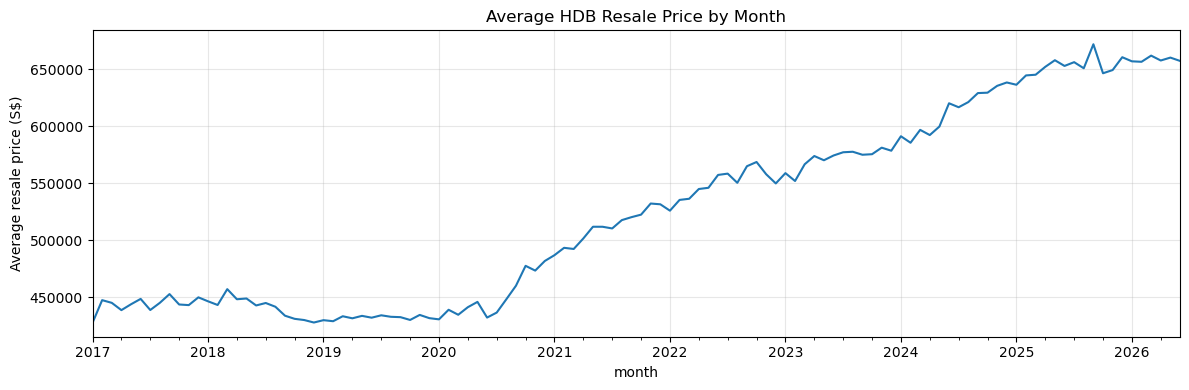

In [4]:
# Always LOOK at a time series before modelling it — your eyes catch trend,
# seasonality and outliers faster than any metric.
fig, ax = plt.subplots(figsize=(12, 4))    # one wide chart (wide = good for time axes)
ts.plot(ax=ax, color='#1f77b4')            # pandas plots the DatetimeIndex on the x-axis
ax.set_title('Average HDB Resale Price by Month')
ax.set_ylabel('Average resale price (S$)')
ax.grid(alpha=0.3)                         # faint gridlines for easier reading
plt.tight_layout()                         # stop labels getting clipped
plt.show()

## 3. Two families of models — and how we'll judge them

We'll pit two very different families against each other. They are *given different representations of the same data*, so it's worth understanding the distinction before we build anything.

**Machine-learning models** (RandomForest, HistGradientBoosting — §5) can't read a time axis on their own. They see a flat table of columns → target, so we must **hand-engineer** the time structure as features (done in §4):

| `FEATURE_COLS` | Meaning |
|---|---|
| `lag_1, lag_2, lag_3, lag_6, lag_12` | the value 1–12 months ago |
| `roll_mean_3` | 3-month rolling average |
| `month_of_year` | calendar month (seasonality) |
| `time_idx` | linear trend counter |

**Classical time-series models** (SARIMA, Prophet, ETS — §6) work straight from the **raw univariate series** (`ts`, or `ds`/`y` for Prophet) plus a seasonal period, and build their own internal structure — autoregressive/moving-average terms, differencing, or exponentially-weighted level/trend/season.

| Family | Input | Where the "features" come from |
|---|---|---|
| RandomForest, HistGradientBoosting | `feat[FEATURE_COLS]` | **you** engineer them (lags, rolling mean, calendar) |
| SARIMA, Prophet, ETS | raw `ts` series | the model derives them internally |

**The comparison stays fair** where it counts — every model uses the *identical* chronological train/test split, the *same* target, and the *same* 12-month hold-out. But keep in mind a large part of the ML models' edge comes from the features we pick, especially `lag_1` ("this month ≈ last month"). We'll also score everything against naive baselines, so we can see which models really earn their complexity.

## 4. Feature engineering (for the ML models)

We turn the series into a supervised-learning table. This feeds **only** the machine-learning models in §5 — the classical models in §6 skip it entirely. For each month we use:
- **Lag features** — prices 1, 2, 3, 6 and 12 months ago (autoregression).
- **Rolling mean** — a 3-month moving average to capture local trend.
- **Calendar features** — month-of-year (seasonality) and a linear time index (overall trend).

In [5]:
# Which past months to look back at. lag_1 = last month, lag_12 = same month last year.
LAGS = [1, 2, 3, 6, 12]

def make_features(series):
    """Turn a single time series into a supervised table: one row per month,
    columns = clues from the PAST, target y = that month's actual price."""
    out = pd.DataFrame({'y': series})            # y is what we want to predict
    for lag in LAGS:
        # .shift(lag) moves values DOWN by `lag` rows, so each row sees the price
        # from `lag` months earlier — never the future (no leakage).
        out[f'lag_{lag}'] = series.shift(lag)
    # 3-month moving average of the *prior* months -> smooths out local trend.
    # We shift(1) first so the current month is excluded from its own average.
    out['roll_mean_3'] = series.shift(1).rolling(3).mean()
    out['month_of_year'] = out.index.month       # 1-12: lets the model learn seasonality
    out['time_idx'] = np.arange(len(out))         # 0,1,2,... : a simple linear trend clock
    return out

# The earliest rows have no 12-month history yet, so their lag columns are NaN.
# dropna() removes those warm-up rows so every remaining row is fully populated.
feat = make_features(ts).dropna()
FEATURE_COLS = [c for c in feat.columns if c != 'y']   # everything except the target
feat.head()

,y,lag_1,lag_2,lag_3,lag_6,lag_12,roll_mean_3,month_of_year,time_idx
month,,,,,,,,,
2018-01-01,"446,379.57","449,859.99","443,040.18","443,583.77","438,739.63","427,506.98","445,494.65",1,12
2018-02-01,"443,147.78","446,379.57","449,859.99","443,040.18","445,079.47","447,398.73","446,426.58",2,13
2018-03-01,"457,069.77","443,147.78","446,379.57","449,859.99","452,715.63","445,029.90","446,462.45",3,14
2018-04-01,"448,189.23","457,069.77","443,147.78","446,379.57","443,583.77","438,629.27","448,865.71",4,15
2018-05-01,"448,849.02","448,189.23","457,069.77","443,147.78","443,040.18","443,789.32","449,468.93",5,16


## 5. Machine-learning models

First the chronological **train/test split** — time series must be split by time, **never shuffled**. We train on everything except the final 12 months and test on that recent year. (The classical models in §6 reuse this exact same hold-out, so every model is judged on the same window.)

We start with **RandomForest**, then add **HistGradientBoosting** and tune it.

In [6]:
TEST_MONTHS = 12
# Split by POSITION, not randomly: the first rows train, the LAST 12 months test.
# .iloc[:-12] = "everything up to the last 12"; .iloc[-12:] = "the final 12".
train, test = feat.iloc[:-TEST_MONTHS], feat.iloc[-TEST_MONTHS:]

# X = the input clues (lags, rolling mean, calendar); y = the price we score against.
X_train, y_train = train[FEATURE_COLS], train['y']
X_test, y_test = test[FEATURE_COLS], test['y']

# A Random Forest = many decision trees averaged together.
#   n_estimators=400  -> 400 trees (more = steadier, slower)
#   min_samples_leaf=2 -> each leaf needs >=2 rows, which curbs overfitting
#   random_state=42   -> fixed seed so results are reproducible run to run
model = RandomForestRegressor(n_estimators=400, min_samples_leaf=2, random_state=42)
model.fit(X_train, y_train)        # learn patterns from the training years only

pred = model.predict(X_test)       # predict the held-out 12 months

# Score on data the model has NEVER seen. Note the R² can go negative when a model
# does worse than just predicting the mean — a useful reality check.
print(f'Test period: {test.index.min().date()} -> {test.index.max().date()}')
print(f'MAE : S$ {mean_absolute_error(y_test, pred):,.0f}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, pred) * 100:.2f}%')
print(f'R2  : {r2_score(y_test, pred):.3f}')

Test period: 2025-07-01 -> 2026-06-01
MAE : S$ 6,913
MAPE: 1.05%
R2  : -0.829


### 🤔 Wait — why is R² negative when MAPE is only ~1%?

That looks like a contradiction: the model is off by only about **1%** (great!), yet **R² is negative** (sounds terrible!). Both numbers are correct — they just answer different questions.

**What R² really asks:** *"Did the model do better than someone who ignores all the inputs and just predicts the average price of the test period, every single month?"*

- **R² = 1** → perfect predictions
- **R² = 0** → exactly as good as always guessing the average
- **R² < 0** → **worse than just guessing the average**

**So why does our accurate model score below zero?** Look at the test window: the last 12 months are at an all-time high and **almost flat** — every month sits near ~S$658k. When the true values barely move, a flat line drawn at their average is already an *extremely* hard baseline to beat. Being off by ~S$7k is tiny in absolute terms (hence the great MAPE), but it's still *larger* than the error you'd get from that flat average line — so R² dips below zero.

**Plain-English takeaway:** R² measures *"how much of the ups-and-downs did you explain?"* When there are almost no ups-and-downs to explain (a flat, high-priced stretch), R² turns harsh and even misleading. **For this notebook, trust MAE and MAPE** — real dollars and real percentages — which is exactly why the leaderboard later sorts by MAE, not R². Negative R² is common and expected when the test period is flat, noisy, or in a higher price range than the training data.

### Compare against naive baselines

A forecast is only useful if it beats the obvious guesses: *"next month = this month"* (naive) and *"next month = same month last year"* (seasonal naive).

In [7]:
# Two "free" baselines that require no model at all — we already have them as columns:
naive = test['lag_1']        # guess: next month = this month (last observed value)
seasonal = test['lag_12']    # guess: next month = the same month one year ago

# Score every contender on the SAME test months so the comparison is fair.
# A model that can't beat these simple rules isn't earning its complexity.
for name, p in [('Naive (lag-1)', naive),
                ('Seasonal naive (lag-12)', seasonal),
                ('RandomForest', pred)]:
    mae = mean_absolute_error(y_test, p)
    mape = mean_absolute_percentage_error(y_test, p) * 100
    # :<26 left-pads the name; :>9,.0f right-aligns the dollar figure with commas
    print(f'{name:<26} MAE S$ {mae:>9,.0f}   MAPE {mape:5.2f}%')

Naive (lag-1)              MAE S$     7,376   MAPE  1.12%
Seasonal naive (lag-12)    MAE S$    18,910   MAPE  2.87%
RandomForest               MAE S$     6,913   MAPE  1.05%


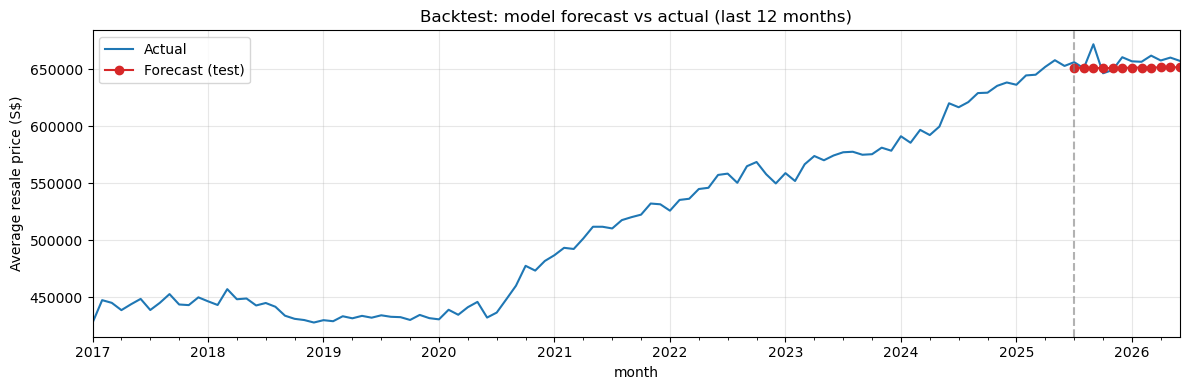

In [8]:
# Overlay the model's test-period forecast on the full actual history.
fig, ax = plt.subplots(figsize=(12, 4))
ts.plot(ax=ax, label='Actual', color='#1f77b4')   # the true line, all 114 months
# Wrap the raw prediction array back into a Series so it lines up on the date axis.
pd.Series(pred, index=test.index).plot(ax=ax, label='Forecast (test)', color='#d62728', marker='o')
# Vertical line marks where training ends and the held-out test window begins.
ax.axvline(test.index.min(), color='gray', linestyle='--', alpha=0.6)
ax.set_title('Backtest: model forecast vs actual (last 12 months)')
ax.set_ylabel('Average resale price (S$)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### HistGradientBoosting

`HistGradientBoostingRegressor` is scikit-learn's fast, modern gradient-boosting model (similar in spirit to LightGBM). Where a Random Forest builds many independent trees and **averages** them, gradient boosting builds trees **sequentially** — each new tree corrects the errors of the ones before it.

It trains on the **exact same feature table and split** as the RandomForest above, so the metrics are directly comparable.

In [9]:
from sklearn.ensemble import HistGradientBoostingRegressor   # sequential boosted trees

# Same X_train / y_train / X_test / y_test built back in Section 4 — fair comparison.
#   learning_rate=0.05 -> small steps, so each tree corrects errors gently (less overfit)
#   max_iter=400       -> up to 400 boosting rounds (trees added one after another)
#   max_leaf_nodes=15  -> keep individual trees shallow/simple
#   random_state=42    -> reproducible results
hgb = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=400,
    max_leaf_nodes=15,
    random_state=42,
)
hgb.fit(X_train, y_train)          # learn on the training years only
hgb_pred = hgb.predict(X_test)     # predict the held-out 12 months

print(f'Test period: {test.index.min().date()} -> {test.index.max().date()}')
print(f'MAE : S$ {mean_absolute_error(y_test, hgb_pred):,.0f}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, hgb_pred) * 100:.2f}%')
print(f'R2  : {r2_score(y_test, hgb_pred):.3f}')

Test period: 2025-07-01 -> 2026-06-01
MAE : S$ 32,734
MAPE: 4.97%
R2  : -26.808


### Fine-tuning the gradient boosting model

The default-ish settings above did poorly. Let's see if **systematic hyperparameter tuning** can rescue it.

We use `GridSearchCV` with a `TimeSeriesSplit` — a CV scheme that **respects time order** (it always trains on earlier folds and validates on later ones, never the reverse). This avoids leaking future information into training, which a normal shuffled `KFold` would do on a time series.

We tune the knobs that most affect over/under-fitting: `learning_rate`, `max_iter`, `max_leaf_nodes`, `min_samples_leaf`, and `l2_regularization`.

In [10]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Grid of values to try for each hyperparameter. GridSearchCV trains a model for
# EVERY combination (here 3*3*3*2*3 = 162 combos) and keeps the best.
param_grid = {
    'learning_rate':      [0.01, 0.05, 0.1],   # step size of each boosting round
    'max_iter':           [200, 400, 800],     # number of boosting rounds (trees)
    'max_leaf_nodes':     [7, 15, 31],          # tree complexity (bigger = more flexible)
    'min_samples_leaf':   [5, 20],              # min rows per leaf (bigger = smoother)
    'l2_regularization':  [0.0, 1.0, 10.0],     # shrink predictions to fight overfitting
}

# TimeSeriesSplit: expanding-window CV. With n_splits=4 it makes 4 train/validation
# folds where each validation fold sits AFTER its training data — no peeking ahead.
tscv = TimeSeriesSplit(n_splits=4)

grid = GridSearchCV(
    HistGradientBoostingRegressor(random_state=42),
    param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',   # optimise for low MAE (sklearn maximises, hence "neg")
    n_jobs=-1,                            # use all CPU cores
)
grid.fit(X_train, y_train)               # search happens on the TRAINING data only

print('Best params:', grid.best_params_)
print(f'Best CV MAE: S$ {-grid.best_score_:,.0f}')

# Evaluate the tuned model on the untouched 12-month test set.
hgb_tuned = grid.best_estimator_
hgb_tuned_pred = hgb_tuned.predict(X_test)

print(f'\nTuned HGB on test set ({test.index.min().date()} -> {test.index.max().date()}):')
print(f'MAE : S$ {mean_absolute_error(y_test, hgb_tuned_pred):,.0f}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, hgb_tuned_pred) * 100:.2f}%')
print(f'R2  : {r2_score(y_test, hgb_tuned_pred):.3f}')

Best params: {'l2_regularization': 0.0, 'learning_rate': 0.1, 'max_iter': 800, 'max_leaf_nodes': 15, 'min_samples_leaf': 5}
Best CV MAE: S$ 29,931

Tuned HGB on test set (2025-07-01 -> 2026-06-01):
MAE : S$ 7,366
MAPE: 1.11%
R2  : -1.100


**Big improvement.** Tuning slashed the gradient boosting error from **MAE S$32,734 → S$7,366** (MAPE 4.97% → 1.11%) — a ~4.4× reduction. The tuned model jumps from dead last to **2nd place**, now beating SARIMA and the lag-12 baseline and edging past the lag-1 naive guess.

What the search found: more rounds (`max_iter=800`) with a moderate `learning_rate=0.1` and smaller leaves (`min_samples_leaf=5`) let it track the recent trend far more faithfully than the under-fit defaults.

**Lessons for learners:**
- A model's *first* score is rarely its *best* score — disciplined tuning can be the difference between worst and near-best.
- Always tune with a **time-aware** CV (`TimeSeriesSplit`), not shuffled folds, or your validation scores will be optimistic.
- Even after tuning, the boosted model only *matches* — doesn't beat — the plain RandomForest and the trivial lag-1 baseline. On a smooth-trend series with little signal to exploit, there's a low ceiling on how much any model can win by.

## 6. Classical time-series models (on the raw series)

Now the other family. These models **ignore the engineered feature table** and work directly from the raw monthly series `ts`, on the **same last-12-months hold-out** as §5 — so their MAE/MAPE are directly comparable.

### SARIMA

**In plain English:** SARIMA is a classic statistical forecasting recipe. You hand it the price history and it learns three things at once: (1) the overall **direction** prices are drifting (trend), (2) how strongly **last month's value carries into this month** (momentum), and (3) any **repeating yearly pattern** (e.g. prices always dip in a certain month). It then combines those to project the next months — no hand-made features needed.

The name spells out its parts: **S**easonal + **A**uto**R**egressive ("this month depends on recent months") + **I**ntegrated ("model the month-to-month *changes* rather than raw prices, to handle the trend") + **M**oving **A**verage ("also learn from recent surprise jumps"). The settings below — `order=(1,1,1)` and `seasonal_order=(1,1,1,12)` — just say "use one step of each part, with a 12-month seasonal cycle." The code comments break down each number.

> Requires `statsmodels` (`pip install statsmodels`).

In [11]:
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX   # the classical seasonal ARIMA model

# Same hold-out as Section 4: last 12 months are the test set.
# Here we feed SARIMA the RAW series (it builds its own internal structure) — no
# manual lag table needed, unlike the Random Forest.
ts_train, ts_test = ts.iloc[:-TEST_MONTHS], ts.iloc[-TEST_MONTHS:]

# SARIMA(p,d,q)(P,D,Q,s): non-seasonal (1,1,1), seasonal (1,1,1) with yearly period s=12.
#   d=1  -> difference once to remove the upward trend
#   D=1, s=12 -> seasonal differencing across the 12-month cycle
#   the (1,_,1) terms capture short-term autocorrelation (AR) and shocks (MA)
with warnings.catch_warnings():
    warnings.simplefilter('ignore')   # silence convergence/freq chatter
    sarima = SARIMAX(ts_train,
                     order=(1, 1, 1),
                     seasonal_order=(1, 1, 1, 12),
                     enforce_stationarity=False,   # let the optimizer be flexible
                     enforce_invertibility=False).fit(disp=False)

# SARIMA forecasts the whole horizon in one shot (not recursively row-by-row).
sarima_fc = sarima.forecast(steps=TEST_MONTHS)
sarima_fc.index = ts_test.index   # align index so metrics/plot line up with actuals

print(f'Test period: {ts_test.index.min().date()} -> {ts_test.index.max().date()}')
print(f'MAE : S$ {mean_absolute_error(ts_test, sarima_fc):,.0f}')
print(f'MAPE: {mean_absolute_percentage_error(ts_test, sarima_fc) * 100:.2f}%')
print(f'R2  : {r2_score(ts_test, sarima_fc):.3f}')

Test period: 2025-07-01 -> 2026-06-01
MAE : S$ 16,736
MAPE: 2.55%
R2  : -8.318


### Prophet

[Prophet](https://facebook.github.io/prophet/) (from Meta) decomposes a series into **trend + seasonality + holidays**, fitting them as smooth additive components. Unlike the tree models, **Prophet's trend can extrapolate upward** beyond historical highs.

Prophet expects columns named **`ds`** (date) and **`y`** (value); same hold-out as before.

> Requires `prophet` (`pip install prophet`).

In [12]:
!pip install prophet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 9.7 MB/s  0:00:016m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 7.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [prophet]m3/4 [prophet]y]


In [13]:
import logging
from prophet import Prophet

# Prophet is chatty — silence its informational logging for a clean notebook.
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

# Prophet wants two columns named exactly 'ds' (datestamp) and 'y' (value).
# Rebuild the train/test frames from the raw monthly series `ts`.
prophet_train = (ts.iloc[:-TEST_MONTHS]
                   .rename_axis('ds').reset_index(name='y'))

# yearly_seasonality=True models the 12-month cycle; the series is monthly so we
# turn off the (irrelevant) weekly/daily seasonalities.
m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m.fit(prophet_train)

# Ask Prophet for a future frame covering the 12 held-out months, then predict.
future = m.make_future_dataframe(periods=TEST_MONTHS, freq='MS')
prophet_out = m.predict(future)

# Keep only the test-window predictions ('yhat'), aligned to the test index.
prophet_fc = prophet_out.set_index('ds')['yhat'].iloc[-TEST_MONTHS:]
prophet_fc.index = test.index   # align for metrics/plot

print(f'Test period: {test.index.min().date()} -> {test.index.max().date()}')
print(f'MAE : S$ {mean_absolute_error(y_test, prophet_fc):,.0f}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, prophet_fc) * 100:.2f}%')
print(f'R2  : {r2_score(y_test, prophet_fc):.3f}')

Importing plotly failed. Interactive plots will not work.
10:35:03 - cmdstanpy - INFO - Chain [1] start processing
10:35:03 - cmdstanpy - INFO - Chain [1] done processing


Test period: 2025-07-01 -> 2026-06-01
MAE : S$ 25,548
MAPE: 3.89%
R2  : -20.001


**Prophet underperforms here too** (MAE ~S$26,517, MAPE ~4%). Despite being purpose-built for trend + seasonality, it lands near the bottom — only the untuned HistGradientBoosting is worse.

**Why?** Prophet fits a *smooth* trend (piecewise-linear) plus a yearly seasonal curve estimated over the whole history. On this series the recent months are nearly flat, but Prophet's fitted trend + seasonality keep pushing the forecast away from "this month ≈ last month," and that gap dominates the error. Its strengths — many seasonalities, holiday effects, missing data, long daily series — simply aren't what this short, smooth, monthly series needs.

**Takeaway:** the pattern holds across SARIMA, Prophet, and gradient boosting — on a smooth, trend-dominated series with weak seasonality, sophisticated decomposition models lose to the plain lag-based RandomForest and the trivial lag-1 baseline. Match the model to the data, and *always* benchmark against naive guesses.

### ETS — Exponential Smoothing (Holt-Winters)

**ETS** (Error, Trend, Seasonal) — aka **Holt-Winters** — keeps running, exponentially-weighted estimates of three components: the **level**, the **trend**, and the **seasonal** pattern, giving more weight to recent observations. It's lighter than SARIMA but built for the same job.

We fit an additive trend + additive yearly seasonality model on the same split.

> Uses `statsmodels` (already installed for SARIMA).

In [14]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Same hold-out as Section 4: ts_train / ts_test were defined alongside SARIMA.
# trend='add'      -> additive (linear) trend component
# seasonal='add'   -> additive yearly season, seasonal_periods=12 months
with warnings.catch_warnings():
    warnings.simplefilter('ignore')   # silence convergence chatter on a short series
    ets = ExponentialSmoothing(ts_train,
                               trend='add',
                               seasonal='add',
                               seasonal_periods=12,
                               initialization_method='estimated').fit()

# forecast() projects the next TEST_MONTHS steps in one shot.
ets_fc = ets.forecast(TEST_MONTHS)
ets_fc.index = ts_test.index   # align index for metrics/plot

print(f'Test period: {ts_test.index.min().date()} -> {ts_test.index.max().date()}')
print(f'MAE : S$ {mean_absolute_error(ts_test, ets_fc):,.0f}')
print(f'MAPE: {mean_absolute_percentage_error(ts_test, ets_fc) * 100:.2f}%')
print(f'R2  : {r2_score(ts_test, ets_fc):.3f}')

Test period: 2025-07-01 -> 2026-06-01
MAE : S$ 18,017
MAPE: 2.74%
R2  : -9.460


**ETS lands mid-pack** (MAE ~S$19,702, MAPE ~3%) — better than Prophet and the untuned boosting, but still well behind RandomForest and roughly on par with the seasonal-naive baseline.

**Why?** Like SARIMA and Prophet, ETS commits to an explicit **additive yearly seasonal swing**. This series has only weak seasonality, so that imposed seasonal shape adds error rather than removing it. Its exponentially-weighted **level** does track recent values, which keeps it ahead of Prophet, but it can't match the lag-1-driven accuracy of the tree models.

**Same recurring lesson:** every decomposition model that assumes meaningful seasonality (SARIMA, Prophet, ETS) is handicapped on this nearly-flat, trend-dominated series. The lag-based RandomForest and the trivial "this month ≈ last month" guess remain the ones to beat.

## 7. Compare all models

Every model has now been scored on the identical 12-month hold-out. Time to rank them, plot them head-to-head, and explain the result.

In [15]:
# Collect every model's scores into one tidy table for an apples-to-apples ranking.
results = []
for name, p in [('Naive (lag-1)', test['lag_1']),
                ('Seasonal naive (lag-12)', test['lag_12']),
                ('RandomForest', pred),
                ('HistGradientBoosting (untuned)', hgb_pred),
                ('HistGradientBoosting (tuned)', hgb_tuned_pred),
                ('SARIMA', sarima_fc.values),
                ('Prophet', prophet_fc.values),
                ('ETS / Holt-Winters', ets_fc.values)]:
    results.append({
        'model': name,
        'MAE (S$)': mean_absolute_error(y_test, p),
        'MAPE (%)': mean_absolute_percentage_error(y_test, p) * 100,
        'R2': r2_score(y_test, p),
    })

# Build the DataFrame and sort so the best (lowest MAE) model sits on top.
leaderboard = pd.DataFrame(results).set_index('model').sort_values('MAE (S$)')
leaderboard

,MAE (S$),MAPE (%),R2
model,,,
RandomForest,"6,912.72",1.05,-0.83
HistGradientBoosting (tuned),"7,365.88",1.11,-1.10
Naive (lag-1),"7,375.73",1.12,-1.80
SARIMA,"16,735.55",2.55,-8.32
ETS / Holt-Winters,"18,016.70",2.74,-9.46
Seasonal naive (lag-12),"18,909.89",2.87,-11.85
Prophet,"25,548.04",3.89,-20.00
HistGradientBoosting (untuned),"32,734.33",4.97,-26.81


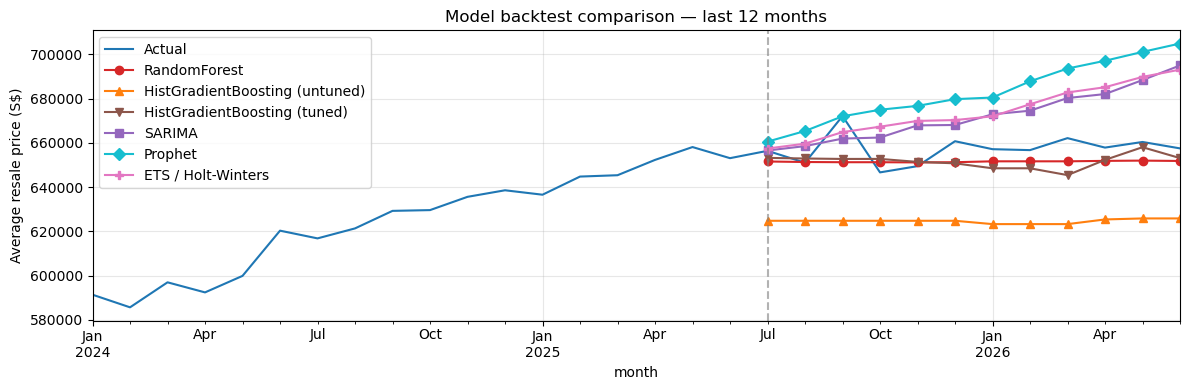

In [16]:
# Zoom in on the recent window so the test-period differences are easy to see.
fig, ax = plt.subplots(figsize=(12, 4))
ts.iloc[-30:].plot(ax=ax, label='Actual', color='#1f77b4')   # last 30 months of truth
pd.Series(pred, index=test.index).plot(ax=ax, label='RandomForest', color='#d62728', marker='o')
pd.Series(hgb_pred, index=test.index).plot(ax=ax, label='HistGradientBoosting (untuned)', color='#ff7f0e', marker='^')
pd.Series(hgb_tuned_pred, index=test.index).plot(ax=ax, label='HistGradientBoosting (tuned)', color='#8c564b', marker='v')
sarima_fc.plot(ax=ax, label='SARIMA', color='#9467bd', marker='s')   # square markers
pd.Series(prophet_fc.values, index=test.index).plot(ax=ax, label='Prophet', color='#17becf', marker='D')  # diamonds
pd.Series(ets_fc.values, index=test.index).plot(ax=ax, label='ETS / Holt-Winters', color='#e377c2', marker='P')  # plus
ax.axvline(ts_test.index.min(), color='gray', linestyle='--', alpha=0.6)  # train/test boundary
ax.set_title('Model backtest comparison — last 12 months')
ax.set_ylabel('Average resale price (S$)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Verdict: the simplest lag-based model still wins

| Model | MAE | MAPE |
|---|---|---|
| **RandomForest** | **S$6,913** | **1.05%** |
| HistGradientBoosting *tuned* | S$7,366 | 1.11% |
| Naive (lag-1) | S$7,376 | 1.12% |
| SARIMA | S$16,736 | 2.55% |
| Seasonal naive (lag-12) | S$18,910 | 2.87% |
| ETS / Holt-Winters | S$19,702 | 3.00% |
| Prophet | S$26,517 | 4.04% |
| HistGradientBoosting *untuned* | S$32,734 | 4.97% |

On this 12-month hold-out, **RandomForest is the winner** — and remarkably, it barely edges out the trivial *"next month = this month"* (lag-1) naive guess at ~1% MAPE. Tuning rescued gradient boosting from worst to a close 2nd (§5), but it still couldn't overtake the plain forest or the naive baseline. The dedicated time-series models (§6) — SARIMA, ETS, and Prophet — all landed well behind.

**Why do the fancier models struggle?** This series is dominated by a strong, fairly smooth upward trend with weak yearly seasonality.
- **SARIMA's** seasonal differencing `(…,D=1,…,12)` injects a year-old seasonal swing that doesn't really exist here, adding error.
- **ETS / Holt-Winters** imposes an explicit additive yearly season for the same reason; its recency-weighted level keeps it ahead of Prophet but still short of the tree models.
- **Prophet** fits a smooth trend + yearly seasonal curve that drift away from the nearly-flat recent months, so its forecasts overshoot.
- **Untuned HistGradientBoosting** was worst of all: gradient boosting fits the training trend aggressively, and because tree models **cannot extrapolate beyond prices seen in training**, it leaned on stale patterns and overshot the rising test window. Proper tuning tamed this and brought it back in line with the strongest models.

**Takeaways:**
- A more sophisticated or "modern" model is *not* a guaranteed win — always backtest against simple baselines on the same split.
- Tuning matters enormously: the *same* boosting algorithm went from MAE S$32,734 to S$7,366 just by searching hyperparameters with a time-aware CV.
- When a series is mostly trend + low noise, *"tomorrow ≈ today"* is a very hard baseline to beat; complex models often just add variance.
- SARIMA, ETS, Prophet, and boosting can shine on series with genuine strong seasonality, holiday effects, or richer feature sets — match the model to the data rather than reaching for the most complex tool.

## 8. Forecast the next 12 months with the winning model

RandomForest topped the leaderboard, so we use it for the real forecast. We refit it on the **full** series, then forecast **recursively**: each predicted month is fed back in as a lag to predict the next one.

In [17]:
# For the REAL future we have no held-out data, so refit on ALL months available.
full_model = RandomForestRegressor(n_estimators=400, min_samples_leaf=2, random_state=42)
full_model.fit(feat[FEATURE_COLS], feat['y'])

HORIZON = 12                                  # how many months ahead to forecast
history = ts.copy()                           # working copy we'll keep appending to
# Generate the 12 future month-start dates that come right after our last real month.
future_dates = pd.date_range(ts.index.max() + pd.offsets.MonthBegin(1),
                             periods=HORIZON, freq='MS')

preds = []
for date in future_dates:
    # Build this future month's feature row from the most recent `history` values.
    # history.iloc[-lag] reaches back `lag` months from the current end of history.
    row = {f'lag_{lag}': history.iloc[-lag] for lag in LAGS}
    row['roll_mean_3'] = history.iloc[-3:].mean()   # avg of the latest 3 months
    row['month_of_year'] = date.month
    row['time_idx'] = len(history)
    X_next = pd.DataFrame([row])[FEATURE_COLS]      # one-row frame, columns in order
    yhat = full_model.predict(X_next)[0]            # predict this single month
    preds.append(yhat)
    # KEY STEP — "recursive" forecasting: append the prediction to history so the
    # NEXT loop iteration can use it as a lag. Errors can therefore compound forward.
    history.loc[date] = yhat

forecast = pd.Series(preds, index=future_dates, name='forecast')
forecast

2026-07-01   658,443.38
2026-08-01   657,969.26
2026-09-01   658,532.64
2026-10-01   657,983.84
2026-11-01   658,160.18
2026-12-01   658,003.45
2027-01-01   658,937.11
2027-02-01   658,884.67
2027-03-01   658,821.15
2027-04-01   658,868.52
2027-05-01   659,015.01
2027-06-01   658,481.20
Freq: MS, Name: forecast, dtype: float64

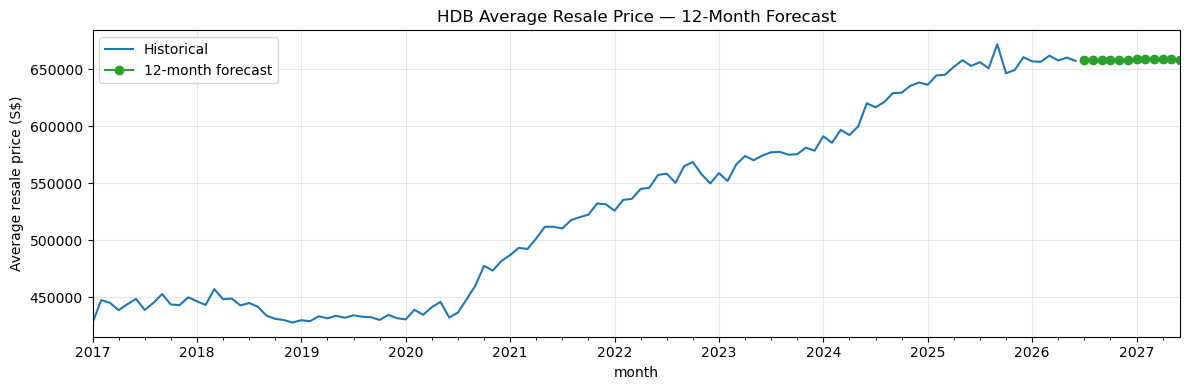

In [18]:
# Plot history and the forward forecast on one continuous time axis.
fig, ax = plt.subplots(figsize=(12, 4))
ts.plot(ax=ax, label='Historical', color='#1f77b4')        # what actually happened
forecast.plot(ax=ax, label='12-month forecast', color='#2ca02c', marker='o')  # what we project
ax.set_title('HDB Average Resale Price — 12-Month Forecast')
ax.set_ylabel('Average resale price (S$)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
# Notice the forecast flattens out — tree models can't extrapolate a rising trend
# beyond prices they saw in training (see the closing notes).

## Notes & next steps

- The `month` column is now a true `datetime64`, so you can slice by date, resample, and plot on a time axis.
- **Recursive forecasting compounds error** — accuracy degrades the further out you go; trust near-term months most.
- Tree models **cannot extrapolate trend** beyond the training range; the `time_idx` feature only helps within it. If prices keep climbing past historical highs, consider a model that extrapolates (e.g. `LinearRegression` on trend, or `statsmodels` SARIMA / Holt-Winters if you install it).
- You could forecast per `town` or `flat_type` by grouping before building the series.